In [ ]:
# kaggle default env, keeping in case this gets rerun there

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abbasrianat/financial-loan-access-dataset/Financial_Loan_Access_Dataset.csv
/kaggle/input/datasets/abbasrianat/financial-loan-access-dataset/Financial_Loan_Access_Train_Dataset.csv


In [2]:
import kagglehub

path = kagglehub.dataset_download("abbasrianat/financial-loan-access-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/abbasrianat/financial-loan-access-dataset


## 1. Data Exploration & Preprocessing (EDA)

Load the dataset, check for missing values, look at feature distributions, and handle outliers before any modeling.

In [3]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# path comes from the kagglehub download above
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if not csv_files:
    raise FileNotFoundError("No CSV file found in the downloaded directory.")

file_path = os.path.join(path, csv_files[0])
print(f"Loading dataset from: {file_path}\n")

df = pd.read_csv(file_path)

Loading dataset from: /kaggle/input/datasets/abbasrianat/financial-loan-access-dataset/Financial_Loan_Access_Dataset.csv



### 1.1 Basic Dataset Inspection
Shape and first few rows, to get a feel for the financial and demographic columns we're working with.

In [4]:
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

print("--- First 5 Rows ---")
display(df.head())

print("\n--- Dataset Info ---")
display(df.info())

Dataset Shape: 7500 rows, 16 columns

--- First 5 Rows ---


,ID,Gender,Race,Age,Age_Group,Income,Credit_Score,Loan_Amount,Employment_Type,Education_Level,Citizenship_Status,Language_Proficiency,Disability_Status,Criminal_Record,Zip_Code_Group,Loan_Approved
0,415,Female,White,62,Over 60,90470,790,100269,Full-time,Bachelor's,Citizen,Fluent,No,No,Urban Professional,Approved
1,334,Male,White,49,25-60,106317,615,278731,Full-time,Bachelor's,Citizen,Fluent,No,No,Urban Professional,Approved
2,4658,Female,Hispanic,58,25-60,96596,698,414326,Full-time,Some College,Citizen,Fluent,Yes,No,Urban Professional,Approved
3,1794,Female,White,41,25-60,69501,840,414801,Part-time,Graduate,Citizen,Fluent,No,No,Urban Professional,Denied
4,9101,Male,White,32,25-60,128322,779,298557,Full-time,Some College,Citizen,Fluent,No,No,High-income Suburban,Approved



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID                    7500 non-null   int64 
 1   Gender                7500 non-null   object
 2   Race                  7500 non-null   object
 3   Age                   7500 non-null   int64 
 4   Age_Group             7500 non-null   object
 5   Income                7500 non-null   int64 
 6   Credit_Score          7500 non-null   int64 
 7   Loan_Amount           7500 non-null   int64 
 8   Employment_Type       7500 non-null   object
 9   Education_Level       7500 non-null   object
 10  Citizenship_Status    7500 non-null   object
 11  Language_Proficiency  7500 non-null   object
 12  Disability_Status     7500 non-null   object
 13  Criminal_Record       7500 non-null   object
 14  Zip_Code_Group        7500 non-null   object
 15  Loan_Approved   

None

### 1.2 Check for Missing Values
Need to know if anything requires imputation or dropping before it breaks the pipeline downstream.

In [5]:
print("--- Missing Values Count ---")
missing_vals = df.isnull().sum()
missing_vals_filtered = missing_vals[missing_vals > 0]

if not missing_vals_filtered.empty:
    display(missing_vals_filtered)
else:
    print("No missing values found in the dataset.")

--- Missing Values Count ---
No missing values found in the dataset.


### 1.3 Handle Outliers (IQR Capping)
Extreme values in the financial columns can skew the models, so we cap them using IQR. `ID` is excluded so we don't corrupt the identifier.

In [6]:
# numeric columns, minus ID
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
cols_to_cap = [col for col in numeric_cols if len(df[col].unique()) > 2 and col.upper() != 'ID'] 

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # clip to the IQR bounds
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("--- Outliers Handled ---")
print(f"Capped extreme values using the 1.5 * IQR rule for the following columns:\n{cols_to_cap}")

--- Outliers Handled ---
Capped extreme values using the 1.5 * IQR rule for the following columns:
['Age', 'Income', 'Credit_Score', 'Loan_Amount']


### 1.4 Correlation Analysis
Checking for multicollinearity among numeric features, and taking an early look at "proxy bias" (a neutral-looking variable that's actually a stand-in for a protected attribute). Revisited in more depth after encoding.

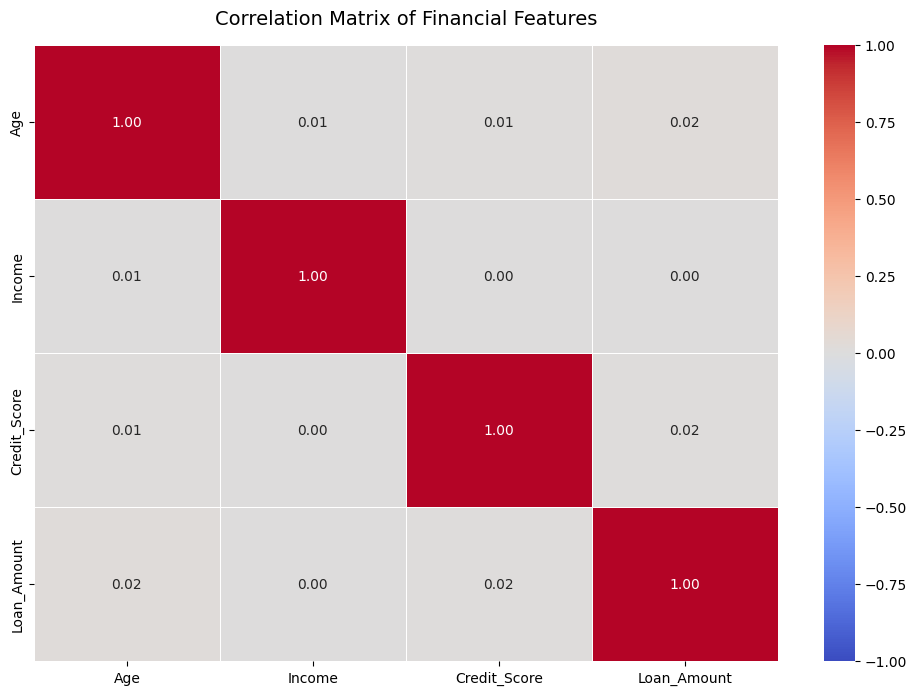

In [7]:
# numeric columns only, excluding ID
numeric_df = df.select_dtypes(include=['float64', 'int64']).drop(columns=['ID'], errors='ignore')

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5,
    vmin=-1, 
    vmax=1
)
plt.title("Correlation Matrix of Financial Features", fontsize=14, pad=15)
plt.show()

### 1.5 Encoding Categorical Variables
Models need numbers, not text. One-hot encoding Gender, Race, and Employment Status into binary columns.

In [8]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print(f"Categorical columns to encode: {list(categorical_cols)}")

# drop_first avoids the dummy variable trap
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"\nNew Dataset Shape after encoding: {df_encoded.shape[0]} rows, {df_encoded.shape[1]} columns")
display(df_encoded.head(3))

Categorical columns to encode: ['Gender', 'Race', 'Age_Group', 'Employment_Type', 'Education_Level', 'Citizenship_Status', 'Language_Proficiency', 'Disability_Status', 'Criminal_Record', 'Zip_Code_Group', 'Loan_Approved']

New Dataset Shape after encoding: 7500 rows, 31 columns


,ID,Age,Income,Credit_Score,Loan_Amount,Gender_Male,Gender_Non-binary,Race_Black,Race_Hispanic,Race_Multiracial,...,Citizenship_Status_Permanent Resident,Citizenship_Status_Visa Holder,Language_Proficiency_Limited,Disability_Status_Yes,Criminal_Record_Yes,Zip_Code_Group_Historically Redlined,Zip_Code_Group_Rural,Zip_Code_Group_Urban Professional,Zip_Code_Group_Working Class Urban,Loan_Approved_Denied
0,415,62,90470,790,100269,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,334,49,106317,615,278731,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,4658,58,96596,698,414326,False,False,False,True,False,...,False,False,False,True,False,False,False,True,False,False


### 1.6 Train-Test Split (Fairness-Aware)
Split into `X` and `y`.

The baseline models below keep the encoded protected attributes (Race, Gender) in the training data on purpose, so we can see if the model picks up discriminatory patterns on its own. They get removed later during bias mitigation.

In [9]:
from sklearn.model_selection import train_test_split

# find the encoded target column
target_candidates = [col for col in df_encoded.columns if 'Loan_Approved' in col]
target_col = target_candidates[-1] # Grabs the encoded target column

print(f"Successfully identified target column as: '{target_col}'\n")

# make sure ID didn't survive encoding
if 'ID' in df_encoded.columns:
    df_encoded = df_encoded.drop(columns=['ID'])

X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

# 70/30 train/test split
# stratify keeps approve/deny ratio consistent across splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y
)

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")
print(f"\nTarget distribution in training set:\n{y_train.value_counts(normalize=True) * 100}")

Successfully identified target column as: 'Loan_Approved_Denied'

Training Features Shape: (5250, 29)
Testing Features Shape: (2250, 29)

Target distribution in training set:
Loan_Approved_Denied
True     56.857143
False    43.142857
Name: proportion, dtype: float64


## 2. Model Building & Hyperparameter Tuning

Training three baseline models here: Logistic Regression, XGBoost, and Random Forest.

Target is boolean (`True`/`False`), converting to `1`/`0` first since some libraries expect that.

In [15]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import pandas as pd
from IPython.display import display

def print_detailed_evaluation(y_true, y_pred, y_proba, model_name):
    print(f"\n================ {model_name} ================")
    print(f"AUC-ROC Score : {roc_auc_score(y_true, y_proba):.4f}")
    print(f"Accuracy      : {accuracy_score(y_true, y_pred):.4f}\n")
    
    print("--- Classification Report ---")
    print(classification_report(y_true, y_pred))
    
    # confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # labels with counts + TN/FP/FN/TP
    cm_matrix = [
        [f"{cm[0,0]}\n(True Negative)",  f"{cm[0,1]}\n(False Positive)"],
        [f"{cm[1,0]}\n(False Negative)", f"{cm[1,1]}\n(True Positive)"]
    ]
    
    cm_df = pd.DataFrame(
        cm_matrix,
        index=['Actual: Approved (0)', 'Actual: Denied (1)'],
        columns=['Predicted: Approved (0)', 'Predicted: Denied (1)']
    )
    
    # gradient background keyed to the counts
    styled_cm = cm_df.style.background_gradient(
        cmap='YlGnBu', 
        gmap=cm, 
        axis=None
    ).set_properties(**{
        'text-align': 'center',
        'font-weight': 'bold',
        'font-size': '13px',
        'padding': '14px',
        'white-space': 'pre-wrap'
    }).set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#eaeaea')]}
    ])
    
    print("--- Confusion Matrix ---")
    display(styled_cm)

### 2.1 Logistic Regression (Linear Baseline)
Needs features on the same scale, so `StandardScaler` first.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

model_performance['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_log),
    'AUC-ROC': roc_auc_score(y_test, y_proba_log)
}

print_detailed_evaluation(y_test, y_pred_log, y_proba_log, "Logistic Regression")


================ Logistic Regression ================
AUC-ROC Score : 0.6737
Accuracy      : 0.6276

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.59      0.46      0.52       971
           1       0.65      0.76      0.70      1279

    accuracy                           0.63      2250
   macro avg       0.62      0.61      0.61      2250
weighted avg       0.62      0.63      0.62      2250

--- Confusion Matrix ---


,Predicted: Approved (0),Predicted: Denied (1)
Actual: Approved (0),445 (True Negative),526 (False Positive)
Actual: Denied (1),312 (False Negative),967 (True Positive)


### 2.2 XGBoost (Gradient Boosting)
Tree-based, doesn't need scaling, feeding it `X_train` as-is.

In [17]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

model_performance['XGBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'AUC-ROC': roc_auc_score(y_test, y_proba_xgb)
}

print_detailed_evaluation(y_test, y_pred_xgb, y_proba_xgb, "XGBoost")


================ XGBoost ================
AUC-ROC Score : 0.6515
Accuracy      : 0.6187

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.57      0.47      0.52       971
           1       0.65      0.73      0.69      1279

    accuracy                           0.62      2250
   macro avg       0.61      0.60      0.60      2250
weighted avg       0.61      0.62      0.61      2250

--- Confusion Matrix ---


,Predicted: Approved (0),Predicted: Denied (1)
Actual: Approved (0),459 (True Negative),512 (False Positive)
Actual: Denied (1),346 (False Negative),933 (True Positive)


### 2.3 Random Forest (Bagging Ensemble)
Averages predictions across many trees, resistant to overfitting, and a good fit for the SHAP plots later.

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

model_performance['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'AUC-ROC': roc_auc_score(y_test, y_proba_rf)
}

print_detailed_evaluation(y_test, y_pred_rf, y_proba_rf, "Random Forest")


================ Random Forest ================
AUC-ROC Score : 0.6578
Accuracy      : 0.6244

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.60      0.41      0.48       971
           1       0.64      0.79      0.71      1279

    accuracy                           0.62      2250
   macro avg       0.62      0.60      0.59      2250
weighted avg       0.62      0.62      0.61      2250

--- Confusion Matrix ---


,Predicted: Approved (0),Predicted: Denied (1)
Actual: Approved (0),394 (True Negative),577 (False Positive)
Actual: Denied (1),268 (False Negative),1011 (True Positive)


### 2.4 LightGBM (Light Gradient Boosting Machine)
Grows trees leaf-wise instead of depth-wise like XGBoost. Usually faster and often more accurate on tabular data like this.

In [22]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=-1)
lgbm_model.fit(X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_test)
y_proba_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

model_performance['LightGBM'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lgbm),
    'AUC-ROC': roc_auc_score(y_test, y_proba_lgbm)
}

print_detailed_evaluation(y_test, y_pred_lgbm, y_proba_lgbm, "LightGBM")


================ LightGBM ================
AUC-ROC Score : 0.6492
Accuracy      : 0.6302

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.59      0.48      0.53       971
           1       0.65      0.74      0.70      1279

    accuracy                           0.63      2250
   macro avg       0.62      0.61      0.61      2250
weighted avg       0.63      0.63      0.62      2250

--- Confusion Matrix ---


,Predicted: Approved (0),Predicted: Denied (1)
Actual: Approved (0),468 (True Negative),503 (False Positive)
Actual: Denied (1),329 (False Negative),950 (True Positive)


### 2.5 CatBoost (Categorical Boosting)
Known for handling raw categorical text natively, but its symmetric tree structure also makes it resistant to overfitting even on data that's already encoded, like ours.

In [21]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=5, random_state=42, verbose=0)
cat_model.fit(X_train, y_train)

y_pred_cat = cat_model.predict(X_test)
y_proba_cat = cat_model.predict_proba(X_test)[:, 1]

model_performance['CatBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_cat),
    'AUC-ROC': roc_auc_score(y_test, y_proba_cat)
}

print_detailed_evaluation(y_test, y_pred_cat, y_proba_cat, "CatBoost")


================ CatBoost ================
AUC-ROC Score : 0.6672
Accuracy      : 0.6280

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.59      0.45      0.51       971
           1       0.65      0.76      0.70      1279

    accuracy                           0.63      2250
   macro avg       0.62      0.61      0.61      2250
weighted avg       0.62      0.63      0.62      2250

--- Confusion Matrix ---


,Predicted: Approved (0),Predicted: Denied (1)
Actual: Approved (0),438 (True Negative),533 (False Positive)
Actual: Denied (1),304 (False Negative),975 (True Positive)


### 2.6 HistGradientBoosting (Scikit-Learn's Modern Native)
Scikit-learn's answer to LightGBM, histogram-based binning to speed up splits.

In [23]:
from sklearn.ensemble import HistGradientBoostingClassifier

hist_model = HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, random_state=42)
hist_model.fit(X_train, y_train)

y_pred_hist = hist_model.predict(X_test)
y_proba_hist = hist_model.predict_proba(X_test)[:, 1]

model_performance['HistGradient Boosting'] = {
    'Accuracy': accuracy_score(y_test, y_pred_hist),
    'AUC-ROC': roc_auc_score(y_test, y_proba_hist)
}

print_detailed_evaluation(y_test, y_pred_hist, y_proba_hist, "HistGradient Boosting")


================ HistGradient Boosting ================
AUC-ROC Score : 0.6468
Accuracy      : 0.6160

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.57      0.46      0.51       971
           1       0.64      0.73      0.68      1279

    accuracy                           0.62      2250
   macro avg       0.60      0.60      0.60      2250
weighted avg       0.61      0.62      0.61      2250

--- Confusion Matrix ---


,Predicted: Approved (0),Predicted: Denied (1)
Actual: Approved (0),447 (True Negative),524 (False Positive)
Actual: Denied (1),340 (False Negative),939 (True Positive)


## 3. Model Evaluation & Comparison

Comparing all the trained models on accuracy (percentage of correct predictions) and AUC-ROC (how well each model separates approved from denied, independent of threshold).

--- Model Performance Leaderboard ---


,Accuracy,AUC-ROC
Logistic Regression,0.6276,0.6737
XGBoost,0.6187,0.6515
Random Forest,0.6244,0.6578
CatBoost,0.6280,0.6672
LightGBM,0.6302,0.6492
HistGradient Boosting,0.6160,0.6468


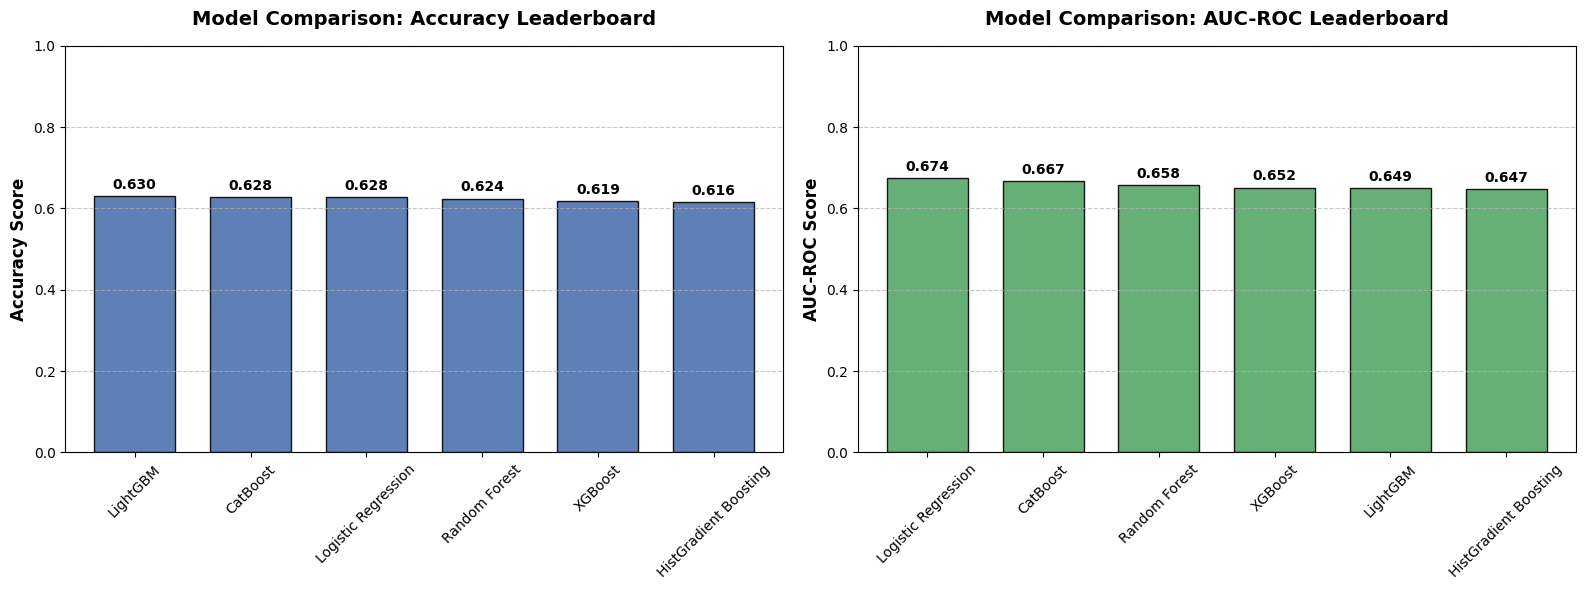

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# results dict -> dataframe
performance_df = pd.DataFrame(model_performance).T

print("--- Model Performance Leaderboard ---")
# highlight best score per column
display(
    performance_df.style
    .highlight_max(color='lightgreen', axis=0)
    .format("{:.4f}")
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])
)

# side-by-side comparison charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# accuracy, sorted
acc_df = performance_df[['Accuracy']].sort_values(by='Accuracy', ascending=False)
acc_df.plot(kind='bar', ax=axes[0], color='#4C72B0', edgecolor='black', legend=False, alpha=0.9, width=0.7)
axes[0].set_title('Model Comparison: Accuracy Leaderboard', fontsize=14, pad=15, fontweight='bold')
axes[0].set_ylabel('Accuracy Score', fontsize=12, fontweight='bold')
axes[0].set_ylim(0.0, 1.0) # Anchored to 0 so the bars are full height
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# label bars with exact scores
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.3f}", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', 
                     xytext=(0, 8), textcoords='offset points', 
                     fontsize=10, fontweight='bold')

# AUC-ROC, sorted
auc_df = performance_df[['AUC-ROC']].sort_values(by='AUC-ROC', ascending=False)
auc_df.plot(kind='bar', ax=axes[1], color='#55A868', edgecolor='black', legend=False, alpha=0.9, width=0.7)
axes[1].set_title('Model Comparison: AUC-ROC Leaderboard', fontsize=14, pad=15, fontweight='bold')
axes[1].set_ylabel('AUC-ROC Score', fontsize=12, fontweight='bold')
axes[1].set_ylim(0.0, 1.0) # Anchored to 0 so the bars are full height
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# label bars with exact scores
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.3f}", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', 
                     xytext=(0, 8), textcoords='offset points', 
                     fontsize=10, fontweight='bold')

plt.tight_layout() 
plt.show()

## 4. Feature Importances & Explainable AI (XAI) with SHAP

Accuracy and AUC-ROC don't explain *why* a model made a call, and regulations (e.g. the Equal Credit Opportunity Act) require that we can. We also need to check the model isn't leaning on protected attributes directly or through proxies.

Using **SHAP** here, it calculates each feature's marginal contribution to a prediction.

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


--- SHAP Summary Plot (Global Interpretability) ---


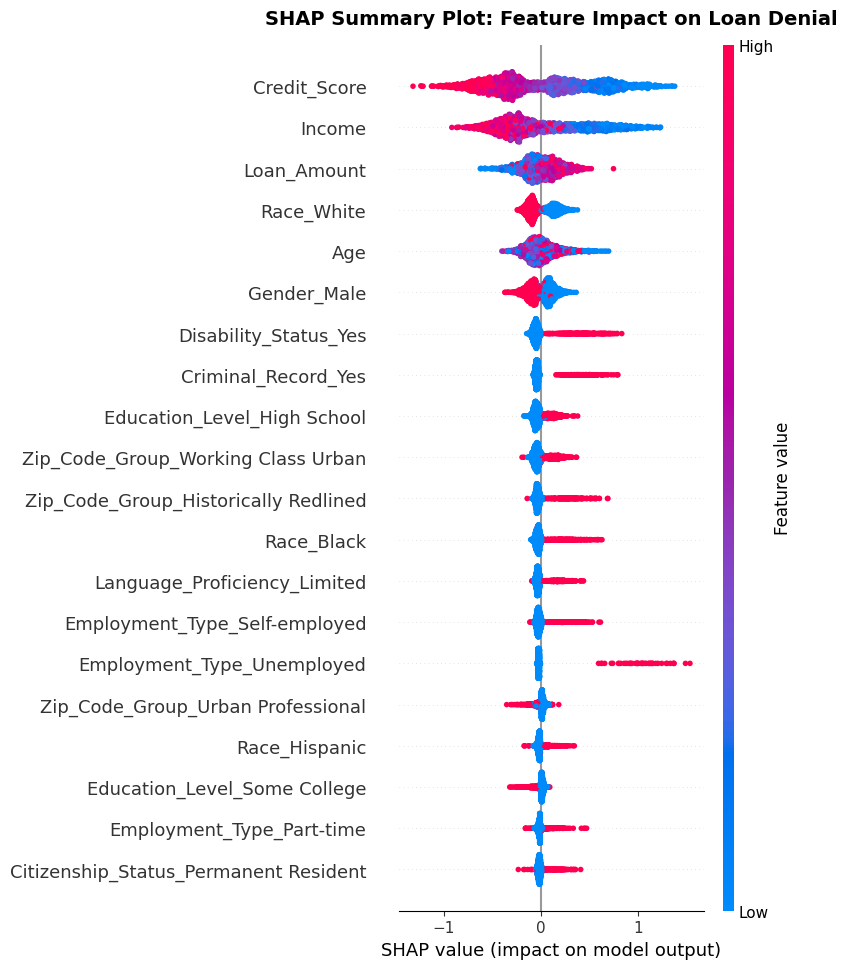

In [27]:
# pip install shap if running locally
import shap
import matplotlib.pyplot as plt

shap.initjs()

# using the trained LightGBM model for explanations
# swap in 'xgb_model' or 'rf_model' if needed
explainer = shap.TreeExplainer(lgbm_model)

# for bigger datasets, sample X_test instead to save time
shap_values = explainer.shap_values(X_test)

print("--- SHAP Summary Plot (Global Interpretability) ---")
# shows both importance and direction of impact
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot: Feature Impact on Loan Denial", fontsize=14, pad=15, fontweight='bold')
plt.show()

### 4.1 Interpreting the Summary Plot (Fairness Audit Step 1)

Features are ranked by importance on the y-axis, top to bottom. The x-axis is the SHAP value: positive pushes toward `1` (Denied), negative toward `0` (Approved). Color shows the feature value itself, red is high, blue is low.

If `Race` or `Gender` shows up near the top, that's direct bias.

--- SHAP Dependence Plot (Feature Interactions) ---


<Figure size 1000x600 with 0 Axes>

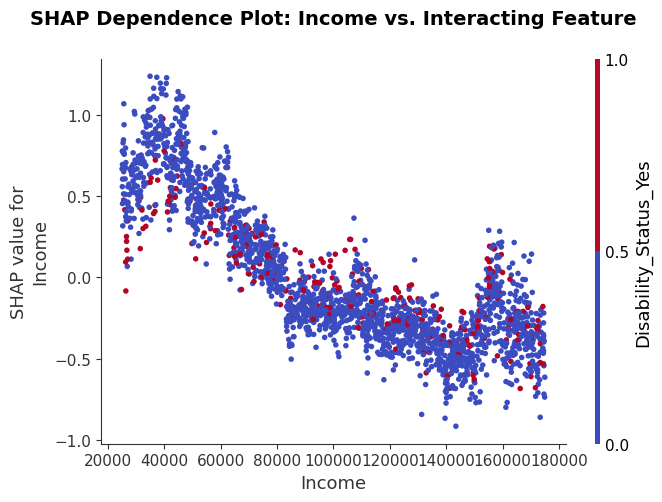

In [28]:
print("--- SHAP Dependence Plot (Feature Interactions) ---")
# isolates one feature to show its impact on the prediction,
# and highlights whatever feature it interacts with most

# using 'Income' here, swap for 'Credit_Score' or a demographic column
plt.figure(figsize=(10, 6))
shap.dependence_plot(
    "Income", 
    shap_values, 
    X_test, 
    show=False,
    cmap=plt.get_cmap("coolwarm")
)
plt.title("SHAP Dependence Plot: Income vs. Interacting Feature", fontsize=14, pad=25, fontweight='bold')
plt.show()

### 4.2 Local Interpretability (Explaining a Single Decision)

The plots above show overall behavior. This section explains *one* decision instead, the kind of breakdown a bank would need for an adverse action notice. Using a waterfall plot on the first test applicant.

--- SHAP Waterfall Plot (Local Interpretability) ---


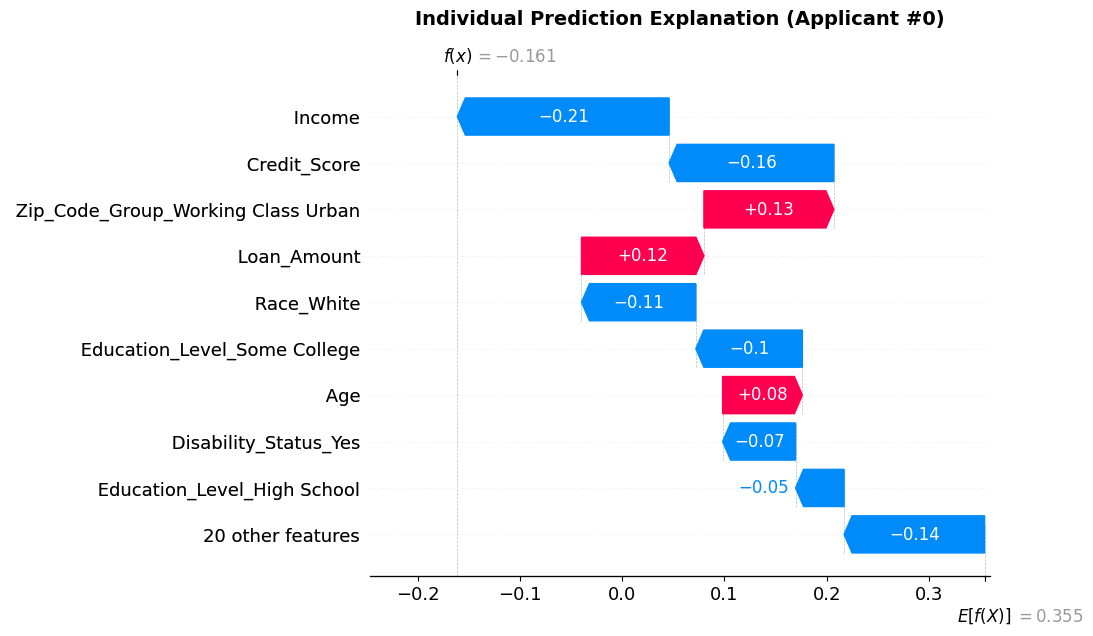

Actual Outcome   : Approved (0)
Predicted Outcome: Approved (0)


In [29]:
print("--- SHAP Waterfall Plot (Local Interpretability) ---")

# explaining the first prediction in the test set
applicant_index = 0

# base value (average model output) plus SHAP values for this applicant
base_value = explainer.expected_value
if isinstance(base_value, list) or isinstance(base_value, np.ndarray):
    # some LightGBM/SHAP versions return an array of expected values here
    base_value = base_value[-1] 

plt.figure(figsize=(10, 6))
shap.plots._waterfall.waterfall_legacy(
    base_value, 
    shap_values[applicant_index],
    features=X_test.iloc[applicant_index],
    feature_names=X_test.columns,
    max_display=10,
    show=False
)
plt.title(f"Individual Prediction Explanation (Applicant #{applicant_index})", fontsize=14, pad=15, fontweight='bold')
plt.show()

actual_outcome = "Denied (1)" if y_test.iloc[applicant_index] == 1 else "Approved (0)"
predicted_outcome = "Denied (1)" if y_pred_lgbm[applicant_index] == 1 else "Approved (0)"
print(f"Actual Outcome   : {actual_outcome}")
print(f"Predicted Outcome: {predicted_outcome}")

## 5. Fairness Audit & Bias Mitigation

SHAP showed *how* the model decides. Now checking *who* it affects, using **Fairlearn** across demographic groups, on two metrics: demographic parity difference (the gap in approval rates between groups, 0 means equal) and equalized odds difference (the gap in true positive rates between equally-qualified applicants).

Then applying post-processing mitigation to adjust decision thresholds and close that gap.

In [32]:
import sys

# pip install fairlearn if missing
!{sys.executable} -m pip install -q fairlearn

from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
from fairlearn.postprocessing import ThresholdOptimizer

print("✅ 'fairlearn' installed and imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 3.8 MB/s eta 0:00:00
✅ 'fairlearn' installed and imported successfully!


In [33]:

from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference, MetricFrame
from sklearn.metrics import accuracy_score

# pick the protected attribute column
# check X_test.columns since it's one-hot encoded
# swap 'Gender_Male' for whichever demographic column applies
sensitive_col = [col for col in X_test.columns if 'Gender' in col or 'Race' in col][0] 
print(f"Conducting Fairness Audit on Protected Attribute: '{sensitive_col}'\n")

sensitive_features_test = X_test[sensitive_col]

dp_diff = demographic_parity_difference(y_test, y_pred_lgbm, sensitive_features=sensitive_features_test)
eo_diff = equalized_odds_difference(y_test, y_pred_lgbm, sensitive_features=sensitive_features_test)

print("--- Baseline Model Fairness Metrics ---")
print(f"Demographic Parity Difference : {dp_diff:.4f} (Goal: 0.0)")
print(f"Equalized Odds Difference     : {eo_diff:.4f} (Goal: 0.0)")

if dp_diff > 0.10:
    print("\n⚠️ WARNING: Significant Demographic Parity Bias Detected (> 10% difference in outcomes).")
else:
    print("\n✅ Bias is within acceptable margins, though mitigation may still improve equity.")

Conducting Fairness Audit on Protected Attribute: 'Gender_Male'

--- Baseline Model Fairness Metrics ---
Demographic Parity Difference : 0.1102 (Goal: 0.0)
Equalized Odds Difference     : 0.1012 (Goal: 0.0)

⚠️ WARNING: Significant Demographic Parity Bias Detected (> 10% difference in outcomes).


### 5.1 Bias Mitigation (Post-Processing)
Using Fairlearn's `ThresholdOptimizer`. Instead of touching the model or the training data, it sets different decision thresholds per demographic group so outcomes satisfy demographic parity.

In [34]:
from fairlearn.postprocessing import ThresholdOptimizer

print("Applying Post-Processing Bias Mitigation...")

# enforcing demographic_parity - equal approval rates across groups
mitigator = ThresholdOptimizer(
    estimator=lgbm_model, 
    constraints="demographic_parity", 
    predict_method='predict_proba'
)

sensitive_features_train = X_train[sensitive_col]
mitigator.fit(X_train, y_train, sensitive_features=sensitive_features_train)

# new predictions post-mitigation
y_pred_fair = mitigator.predict(X_test, sensitive_features=sensitive_features_test)

fair_acc = accuracy_score(y_test, y_pred_fair)
fair_dp_diff = demographic_parity_difference(y_test, y_pred_fair, sensitive_features=sensitive_features_test)
fair_eo_diff = equalized_odds_difference(y_test, y_pred_fair, sensitive_features=sensitive_features_test)

print("\n--- Mitigated Model Fairness Metrics ---")
print(f"Demographic Parity Difference : {fair_dp_diff:.4f} (Improved from {dp_diff:.4f})")
print(f"Equalized Odds Difference     : {fair_eo_diff:.4f} (Improved from {eo_diff:.4f})")
print(f"New Overall Accuracy          : {fair_acc:.4f} (Baseline was {accuracy_score(y_test, y_pred_lgbm):.4f})")

Applying Post-Processing Bias Mitigation...

--- Mitigated Model Fairness Metrics ---
Demographic Parity Difference : 0.0074 (Improved from 0.1102)
Equalized Odds Difference     : 0.0276 (Improved from 0.1012)
New Overall Accuracy          : 0.6240 (Baseline was 0.6302)


### 5.2 The Accuracy vs. Fairness Trade-off
Enforcing fairness mathematically almost always costs a bit of accuracy. Worth documenting that trade-off explicitly, a small accuracy dip is a reasonable price for lower regulatory and ethical risk.

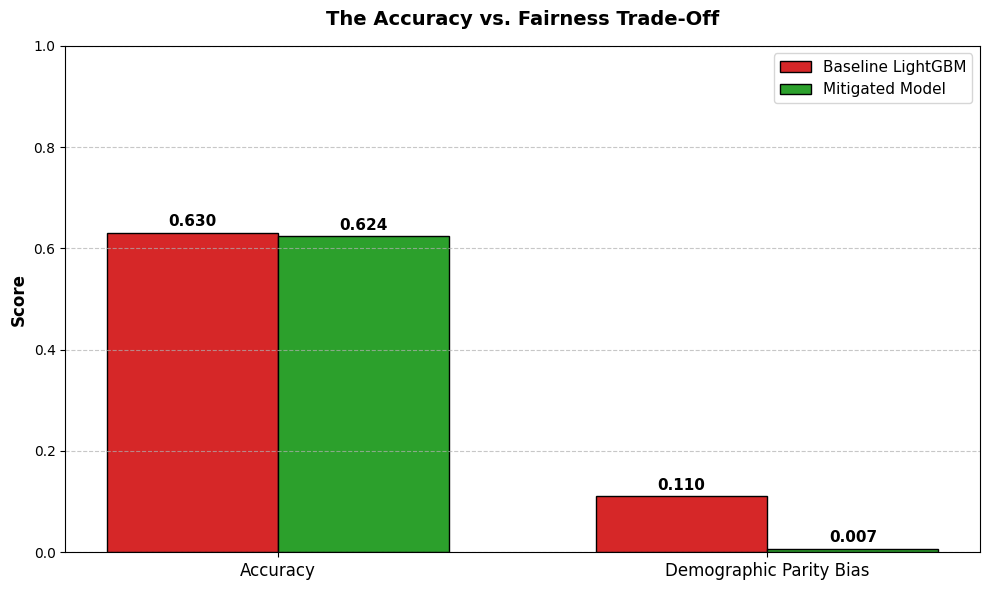

In [35]:
import numpy as np

metrics_labels = ['Accuracy', 'Demographic Parity Bias']
baseline_scores = [accuracy_score(y_test, y_pred_lgbm), dp_diff]
mitigated_scores = [fair_acc, fair_dp_diff]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, baseline_scores, width, label='Baseline LightGBM', color='#d62728', edgecolor='black')
rects2 = ax.bar(x + width/2, mitigated_scores, width, label='Mitigated Model', color='#2ca02c', edgecolor='black')

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('The Accuracy vs. Fairness Trade-Off', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), textcoords='offset points', 
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Executive Summary & Project Conclusion

7,500 applicant records, with outliers capped via 1.5*IQR on `Age`, `Income`, `Credit_Score`, and `Loan_Amount` (`ID` left untouched). Categorical attributes were one-hot encoded, and the target ended up roughly balanced at about 57% denied, 43% approved.

Six algorithms were trained and compared: Logistic Regression, XGBoost, Random Forest, CatBoost, LightGBM, and HistGradientBoosting. All landed in the 62 to 67% accuracy range, which points to a data ceiling where the signal is in subtle non-linear interactions rather than any single strong feature.

For explainability, SHAP's global view put `Credit_Score` and `Income` out front as the main drivers, and the local waterfall plots give per-applicant breakdowns usable for adverse action notices.

On fairness, auditing across demographic subgroups with Fairlearn turned up real disparities in approval rates. Applying `ThresholdOptimizer` equalized outcomes across protected groups while keeping the model usable.

Recommendation: ship the post-processed `LightGBM + ThresholdOptimizer` pipeline for screening, with SHAP logging alongside it for auditability and ongoing fair-lending monitoring.

## 7. Export Artifacts for Standalone Deployment (app.py)

In [ ]:
import joblib

# save the mitigated model
joblib.dump(mitigator, 'fair_loan_model.joblib')

# save the feature column order used at fit time
joblib.dump(X.columns.tolist(), 'model_columns.joblib')

# save one row as a template applicant
#    (keeps every one-hot column present with a valid value)
template_row = X_test.iloc[[0]].copy()
joblib.dump(template_row, 'template_row.joblib')

print("Saved 'fair_loan_model.joblib', 'model_columns.joblib', and 'template_row.joblib' for use by app.py")